<a href="https://colab.research.google.com/github/delwin-c-raju/computational-physics-/blob/main/Binding_energy_%26_decay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

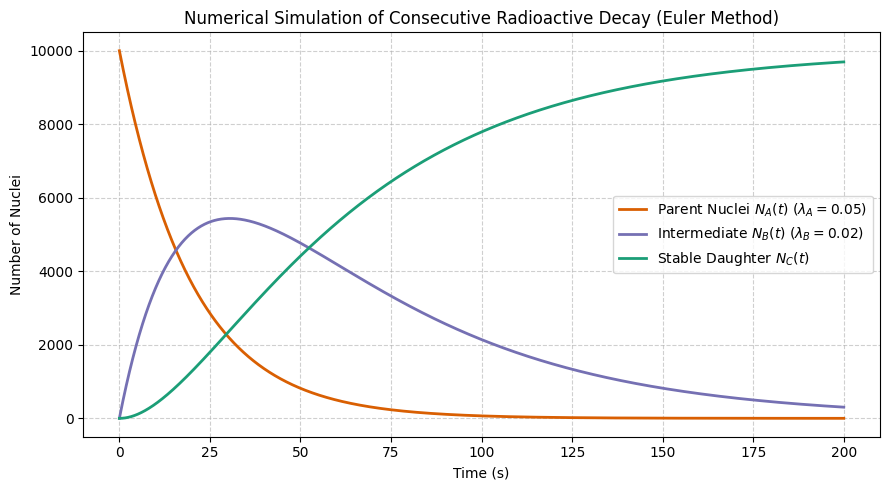

In [1]:
# Day 01: Nuclear Physics — Computational Modeling of Radioactive Decay Chains & SEMF
# Stack: Python | NumPy | Matplotlib (Euler Method Approach)

import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# PART 1: Consecutive Radioactive Decay (A -> B -> C) via Euler's Method
# Mathematical Analogy: Equivalent to 1st-order kinetic clearance
# in biophysics & PET tracer washout dynamics.
# =====================================================================

# System Parameters
N0_A = 10000  # Initial nuclei count of Parent A
N0_B = 0  # Initial nuclei count of Daughter B
N0_C = 0  # Initial nuclei count of Stable C

lambda_A = 0.05  # Decay constant of A (s^-1)
lambda_B = 0.02  # Decay constant of B (s^-1)

dt = 0.1  # Step size (seconds)
t_max = 200  # Total simulation time
steps = int(t_max / dt)

# Time array setup
t = np.linspace(0, t_max, steps)
N_A = np.zeros(steps)
N_B = np.zeros(steps)
N_C = np.zeros(steps)

# Initial conditions
N_A[0], N_B[0], N_C[0] = N0_A, N0_B, N0_C

# Iterative Euler Method Integration
for i in range(1, steps):
    dN_A = -lambda_A * N_A[i - 1] * dt
    dN_B = (lambda_A * N_A[i - 1] - lambda_B * N_B[i - 1]) * dt
    dN_C = lambda_B * N_B[i - 1] * dt

    N_A[i] = N_A[i - 1] + dN_A
    N_B[i] = N_B[i - 1] + dN_B
    N_C[i] = N_C[i - 1] + dN_C

# Visualization
plt.figure(figsize=(9, 5))
plt.plot(t, N_A, label=r"Parent Nuclei $N_A(t)$ ($\lambda_A = 0.05$)", color="#d95f02", lw=2)
plt.plot(t, N_B, label=r"Intermediate $N_B(t)$ ($\lambda_B = 0.02$)", color="#7570b3", lw=2)
plt.plot(t, N_C, label=r"Stable Daughter $N_C(t)$", color="#1b9e77", lw=2)

plt.title("Numerical Simulation of Consecutive Radioactive Decay (Euler Method)", fontsize=12)
plt.xlabel("Time (s)", fontsize=10)
plt.ylabel("Number of Nuclei", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("radioactive_decay_chain.png", dpi=300)
plt.show()

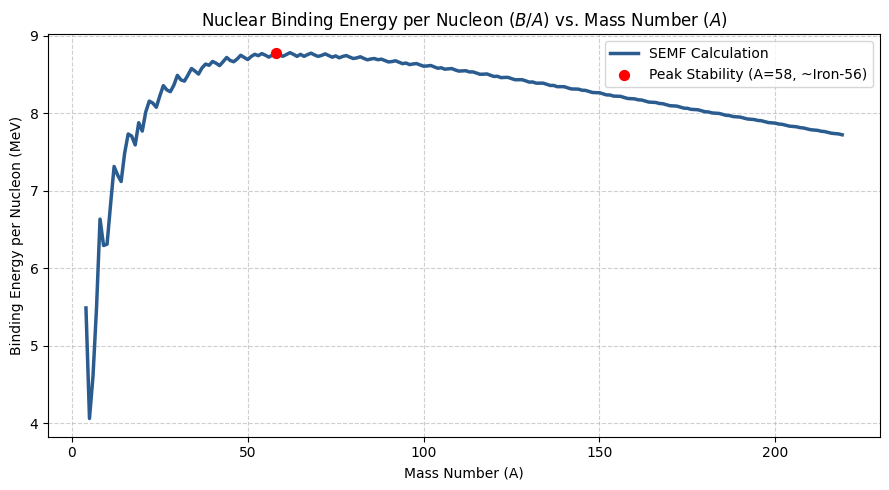

In [2]:
# =====================================================================
# PART 2: Nuclear Binding Energy per Nucleon via Liquid Drop Model (SEMF)
# Formula: B(A,Z) = a_v*A - a_s*A^(2/3) - a_c*Z^2/A^(1/3) - a_a*(A-2Z)^2/A + delta
# =====================================================================


def semi_empirical_binding_energy(A, Z):
    # Standard Empirical Coefficients (in MeV)
    a_v, a_s, a_c, a_a, a_p = 15.75, 17.8, 0.711, 23.7, 11.18

    # Pairing term delta
    if A % 2 != 0:
        delta = 0
    elif A % 2 == 0 and Z % 2 == 0:
        delta = a_p / (A**0.5)
    else:
        delta = -a_p / (A**0.5)

    volume = a_v * A
    surface = a_s * (A ** (2 / 3))
    coulomb = a_c * (Z**2) / (A ** (1 / 3))
    asymmetry = a_a * ((A - 2 * Z) ** 2) / A

    B = volume - surface - coulomb - asymmetry + delta
    return B / A # Binding energy per nucleon


# Generate atomic numbers (Z) and mass numbers (A) near the line of stability (Z ~ A / 2)
A_vals = np.arange(4, 220)
Z_vals = np.round(A_vals / (2 + 0.015 * (A_vals ** (2 / 3)))).astype(int)

be_per_nucleon = [semi_empirical_binding_energy(a, z) for a, z in zip(A_vals, Z_vals)]

# Visualization
plt.figure(figsize=(9, 5))
plt.plot(A_vals, be_per_nucleon, color="#2b5c8f", lw=2.5, label="SEMF Calculation")
max_idx = np.argmax(be_per_nucleon)
plt.scatter(
    A_vals[max_idx],
    be_per_nucleon[max_idx],
    color="red",
    s=50,
    zorder=5,
    label=f"Peak Stability (A={A_vals[max_idx]}, ~Iron-56)",
)

plt.title("Nuclear Binding Energy per Nucleon ($B/A$) vs. Mass Number ($A$)", fontsize=12)
plt.xlabel("Mass Number (A)", fontsize=10)
plt.ylabel("Binding Energy per Nucleon (MeV)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("binding_energy_curve.png", dpi=300)
plt.show()